# Full model of behavior (GLM)

In [1]:
from full_model_behavior import *
from my_fun import fig_size, save_notebook_files

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
default_figsize = np.array(plt.rcParams['figure.figsize'])
sns.set_style('ticks')
sns.set_context('notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

In [4]:
# Parameters
drug = None
iterations = 1
figsize = fig_size(n_cols=2)

## Single animal

23021 trials


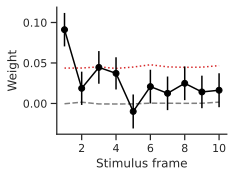

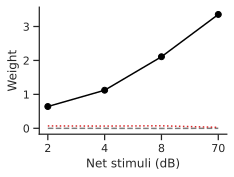

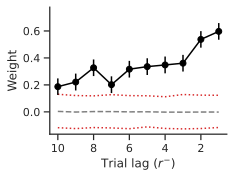

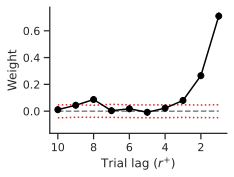

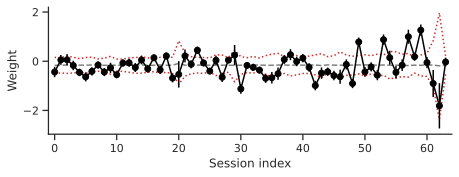

In [25]:
experiment = '2AFC_2'
animal = '333'
# fk = get_fk(experiment=experiment, animal=animal, drug=drug, iterations=iterations, save=True)
with open(f'fk_{animal}', 'rb') as f:
    fk = pickle.load(f)
plot_fk(fk, figsize=figsize)
print(f'{fk.n_trials} trials')

# 2AFC 2

In [ ]:
experiments = ['2AFC_2']
fk_2 = get_mean_fk(experiments=experiments, cherry=True, drug=None, iterations=iterations, save=True)
plot_fk(fk_2, figsize=figsize)
print(f'N = {len(fk_2.animal)} animals, {fk_2.n_trials} trials')

# 2AFC 3

N = 7 animals, 76794 trials


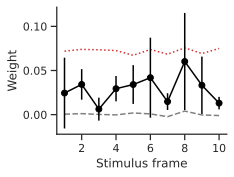

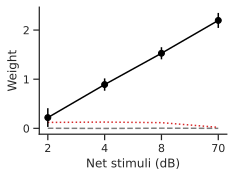

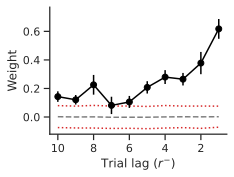

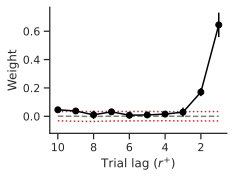

In [40]:
experiments = ['2AFC_3']
# fk_3 = get_mean_fk(experiments=experiments, cherry=True, drug=None, iterations=iterations, save=True)
with open(f'fk_{experiments[0]}', 'rb') as f:
    fk_3 = pickle.load(f)
plot_fk(fk_3, figsize=figsize)
print(f'N = {len(fk_3.animal)} animals, {fk_3.n_trials} trials')

# 2AFC 4

In [ ]:
experiments = ['2AFC_4']
fk_4 = get_mean_fk(experiments=experiments, cherry=True, drug=None, iterations=iterations, save=True)
plot_fk(fk_4, figsize=figsize)
print(f'N = {len(fk_4.animal)} animals, {fk_4.n_trials} trials')

## Mean across animals

N = 25 animals, 323738 trials


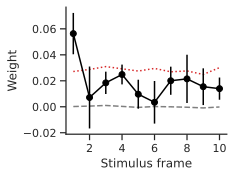

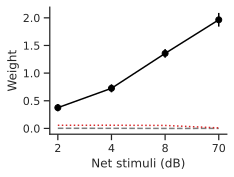

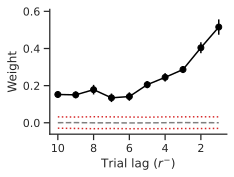

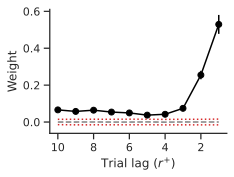

In [29]:
experiments = ['2AFC_2', '2AFC_3', '2AFC_4']
# fk_mean = get_mean_fk(experiments=experiments, cherry=True, drug=None, iterations=iterations, save=True)
with open(f'fk_mean', 'rb') as f:
    fk_mean = pickle.load(f)
plot_fk(fk_mean, figsize=figsize)
print(f'N = {len(fk_mean.animal)} animals, {fk_mean.n_trials} trials')

# 2AFC 6
Drug group

In [ ]:
# experiments = ['2AFC_6']
# # fk = get_mean_fk(experiments=experiments, animals=animals, drug=None, trial_lag=trial_lag, iterations=iterations)
# plot_fk(experiment=experiments, animal=None, drug=None, trial_lag=trial_lag, iterations=iterations, save=save, figsize=figsize)

# Fit exponential to history kernel to find decay time constant (tau)

In [30]:
import numpy as np
from scipy.optimize import curve_fit

# Exponential function
def exp_func(t, A, tau, C):
    return A * np.exp(t / tau) + C  # use -t/tau for decay

In [36]:
fk = fk_mean

## R-

Fitted tau: 2.223502848875412


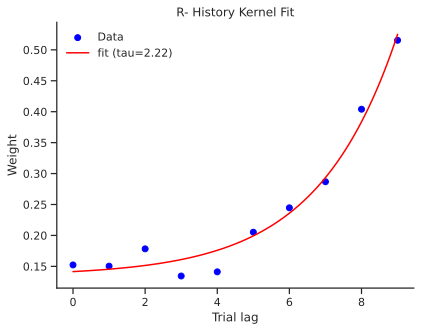

In [37]:
# Fit
x = np.arange(fk.trial_lag)
y = np.array(fk.params_rminus)

popt, pcov = curve_fit(exp_func, x, y, p0=(0.1, 1, 0.1))
A_fit, tau_fit, C_fit = popt
print('Fitted tau:', tau_fit)

# Generate smooth curve
x_fit = np.linspace(0, 9, 100)
y_fit = exp_func(x_fit, A_fit, tau_fit, C_fit)

# Plot
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x_fit, y_fit, color='red', label=f'fit (tau={tau_fit:.2f})')
plt.xlabel('Trial lag')
plt.ylabel('Weight')
plt.title('R- History Kernel Fit')
plt.legend()
sns.despine()

## R+

Fitted tau: 0.9538390367473449


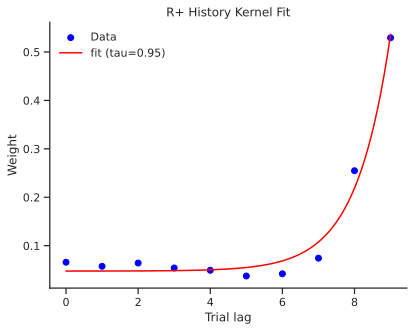

In [38]:
# Fit
x = np.arange(fk.trial_lag)
y = np.array(fk.params_rplus)

popt, pcov = curve_fit(exp_func, x, y, p0=(0.1, 1, 0.1))
A_fit, tau_fit, C_fit = popt
print('Fitted tau:', tau_fit)

# Generate smooth curve
x_fit = np.linspace(0, 9, 100)
y_fit = exp_func(x_fit, A_fit, tau_fit, C_fit)

# Plot
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x_fit, y_fit, color='red', label=f'fit (tau={tau_fit:.2f})')
plt.xlabel('Trial lag')
plt.ylabel('Weight')
plt.title('R+ History Kernel Fit')
plt.legend()
sns.despine()

In [ ]:
np.mean([2.22, 0.95])

# Save all notebook's figures

In [41]:
# # Whole notebook outputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
save_notebook_files('notebook.ipynb')

Saved 15 images to notebook_files/
